In [1]:
from qiskit import __version__

print(__version__)

2.5.2


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

EXERCISE 1: BELL STATES AND MEASUREMENTS

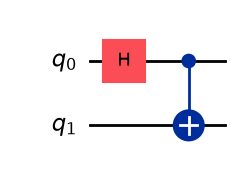

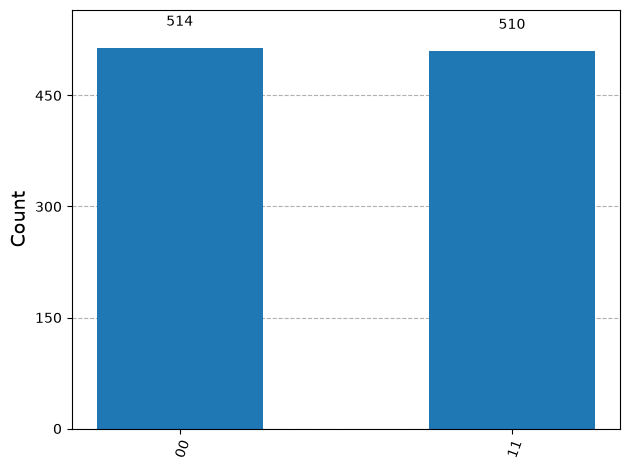

In [11]:


circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0,1)
display(circuit.draw(output="mpl"))

circuit.measure_all()

result = AerSimulator().run(circuit).result()
statistics = result.get_counts()
display(plot_histogram(statistics))


EXERCISE 2: QUANTUM TELEPORTATION

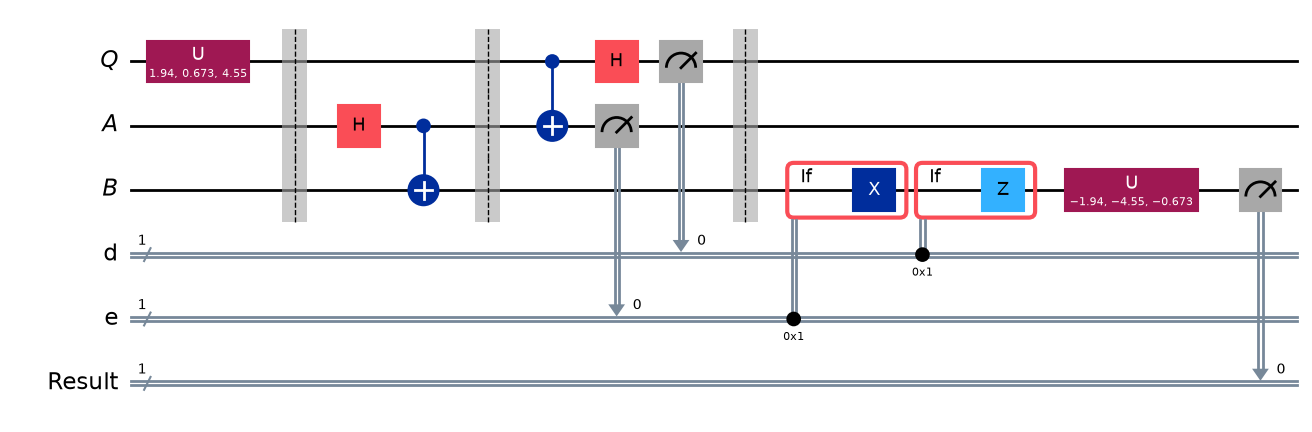

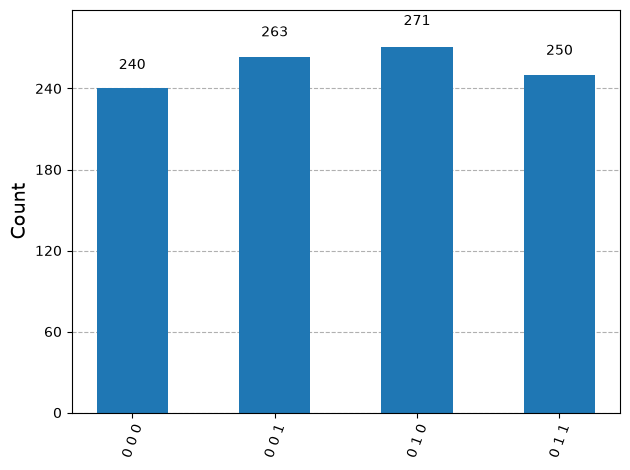

In [16]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

Q = QuantumRegister(1, "Q")
A = QuantumRegister(1, "A")
B = QuantumRegister(1, "B")

d = ClassicalRegister(1, "d")
e = ClassicalRegister(1, "e")


circuit = QuantumCircuit(Q,A,B,d,e)

circuit.append(random_gate, Q)
circuit.barrier()


circuit.h(A)
circuit.cx(A,B)
circuit.barrier()

circuit.cx(Q,A)
circuit.h(Q)
circuit.measure(Q,d)
circuit.measure(A,e)
circuit.barrier()

with circuit.if_test((e, 1)):
    circuit.x(B)
with circuit.if_test((d, 1)):
    circuit.z(B)


circuit.append(random_gate.inverse(), B)
result = ClassicalRegister(1, "Result")
circuit.add_register(result)
circuit.measure(B, result)

display(circuit.draw(output="mpl"))

output = AerSimulator().run(circuit).result()
statistics = output.get_counts()
display(plot_histogram(statistics))


EXERCISE 3: IMPLEMENT DEUSTCH ALGORITHM

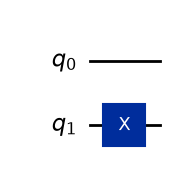

In [19]:
def oracle(case):
    circuit = QuantumCircuit(2)
    if case not in [1,2,3,4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")
    else:
        if case in [2,3]:
            circuit.cx(0,1)
        if case in [3,4]:
            circuit.x(1)
    return circuit

circuit = oracle(4)
display(circuit.draw(output = "mpl"))

In [25]:
def algorithm(oracle):
    protocol = QuantumCircuit(2)
    protocol.x(1)
    protocol.h(0)
    protocol.h(1)
    protocol.barrier()

    protocol.compose(oracle, inplace=True)
    protocol.barrier()

    protocol.h(0)
    output = ClassicalRegister(1, "output")
    protocol.add_register(output)
    protocol.measure(0,output)


    return (protocol,output)



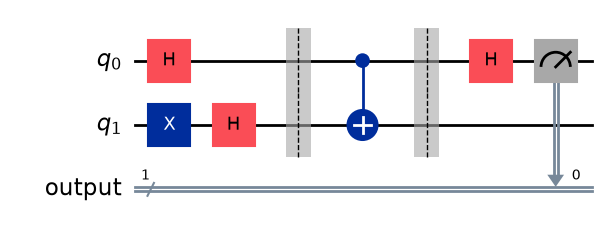

In [27]:
protocol, result = algorithm(oracle(2))
display(protocol.draw(output = "mpl"))

In [29]:
def deutsch_algorithm(function: QuantumCircuit):


    qc, output = algorithm(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if measurements[0] == "0":
        return "constant"
    return "balanced"

In [30]:
function = oracle(2)
display(deutsch_algorithm(function))

'balanced'